In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score
from sklearn.compose import make_column_transformer,ColumnTransformer
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder , StandardScaler , OneHotEncoder

from sklearn.linear_model import LinearRegression , Ridge , ElasticNet , Lasso
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor , VotingRegressor , StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.kernel_ridge import KernelRidge
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
train_df.dtypes[train_df.dtypes != 'object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

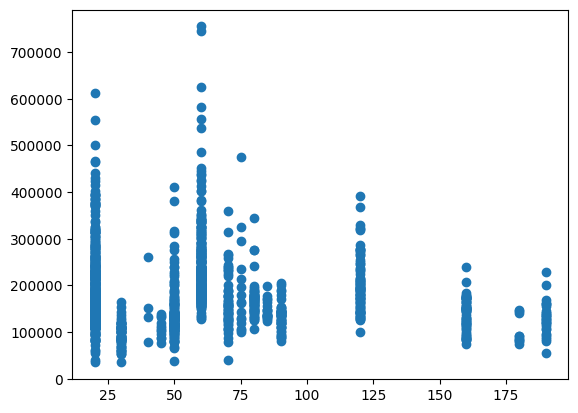

In [6]:
plt.scatter(x = 'MSSubClass' , y = 'SalePrice' , data= train_df)

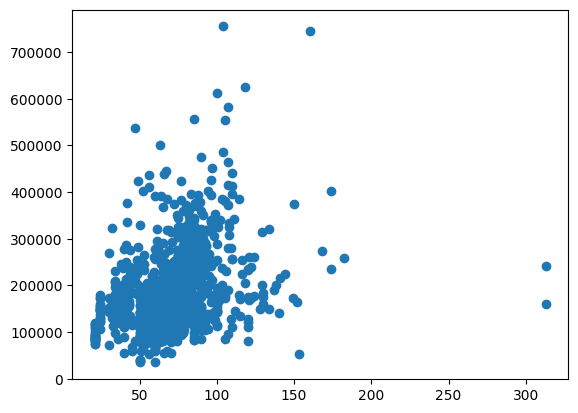

In [7]:
plt.scatter(x = 'LotFrontage' , y = 'SalePrice' , data= train_df)

In [8]:
train_df.query('LotFrontage >300')
#drop 935 and 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


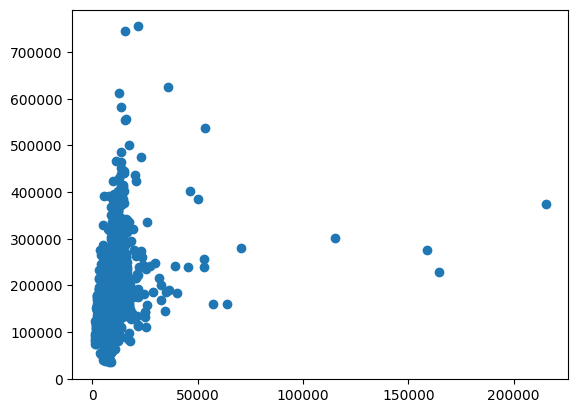

In [9]:
plt.scatter(x = 'LotArea' , y = 'SalePrice' , data= train_df)

In [10]:
train_df.query('LotArea > 55000')
# drop 250 , 314 , 336 , 707
# maybe 1397

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [11]:
pd.Series(stats.zscore(train_df['LotArea']), index=train_df.index).sort_values().tail(10)

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

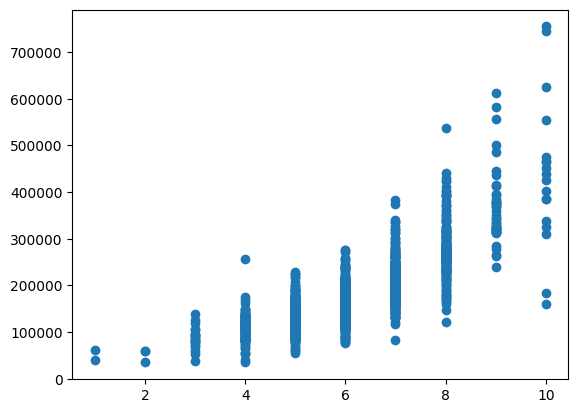

In [12]:
plt.scatter(x = 'OverallQual' , y = 'SalePrice' , data= train_df)

In [13]:
train_df.query('OverallQual == 10 & SalePrice < 250000')
# maybe 524 , 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


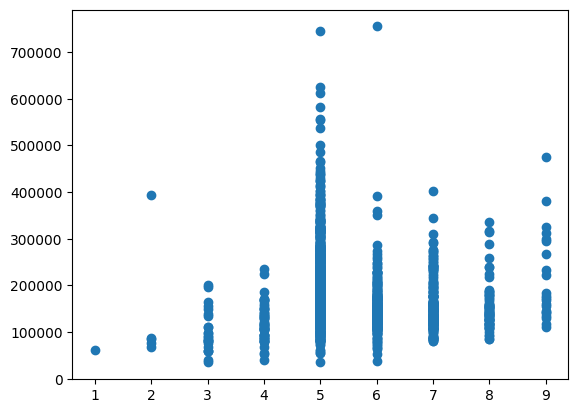

In [14]:
plt.scatter(x = 'OverallCond' , y = 'SalePrice' , data= train_df)

In [15]:
train_df.query('OverallCond == 2')
# drop 379

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
250,251,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
676,677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000


In [16]:
train_df.query('OverallCond == 5 & SalePrice >700000')
# drop 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [17]:
train_df.query('OverallCond == 6 & SalePrice >700000')
# drop 692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


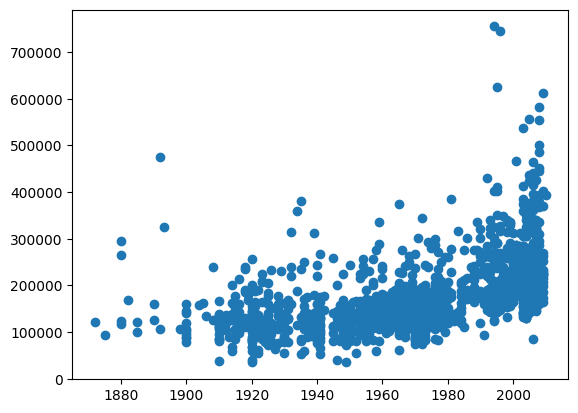

In [18]:
plt.scatter(x = 'YearBuilt' , y = 'SalePrice' , data= train_df)

In [19]:
train_df.query('YearBuilt < 1900 & SalePrice > 400000')
# drop 186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


In [20]:
train_df.query('YearBuilt < 2000 & SalePrice > 700000')
# 692 , 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


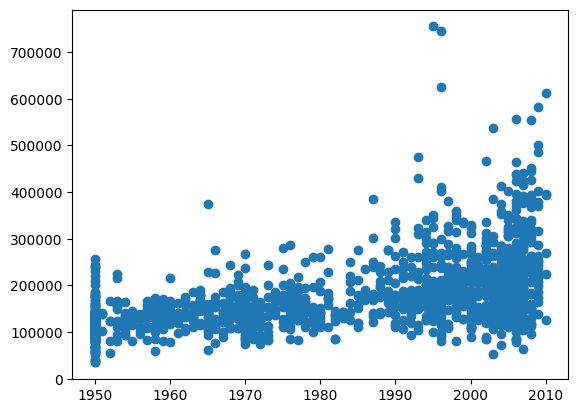

In [21]:
plt.scatter(x = 'YearRemodAdd' , y = 'SalePrice' , data= train_df)

In [22]:
train_df.query('YearRemodAdd < 1970 & SalePrice > 300000')
# 314


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000


In [23]:
train_df.query('YearRemodAdd < 2000 & SalePrice > 600000')
# 692 , 1170 , 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


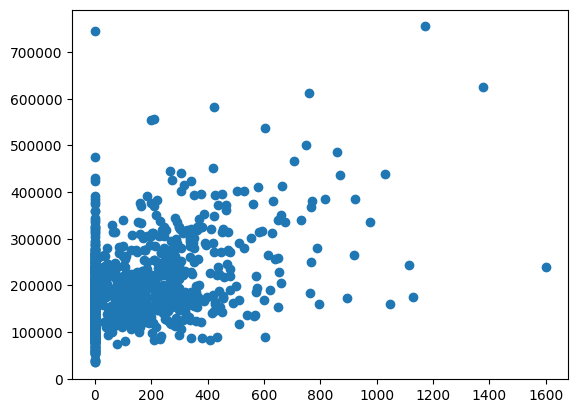

In [24]:
plt.scatter(x = 'MasVnrArea' , y = 'SalePrice' , data= train_df)

In [25]:
train_df.query('MasVnrArea < 200 & SalePrice >700000')
# 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [26]:
train_df.query('MasVnrArea > 1160 ')
# 298 , 692 , 1170

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000


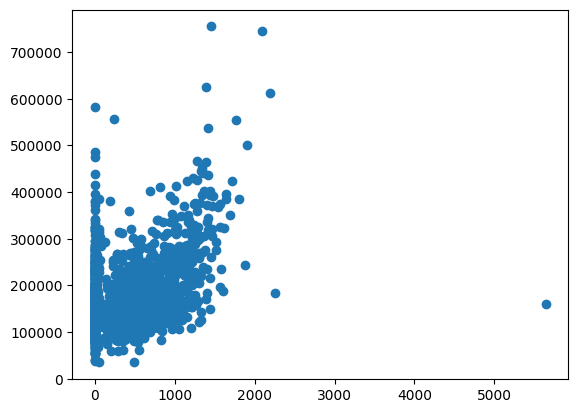

In [27]:
plt.scatter(x = 'BsmtFinSF1' , y = 'SalePrice' , data= train_df)

In [28]:
train_df.query('BsmtFinSF1 > 5000 ')
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


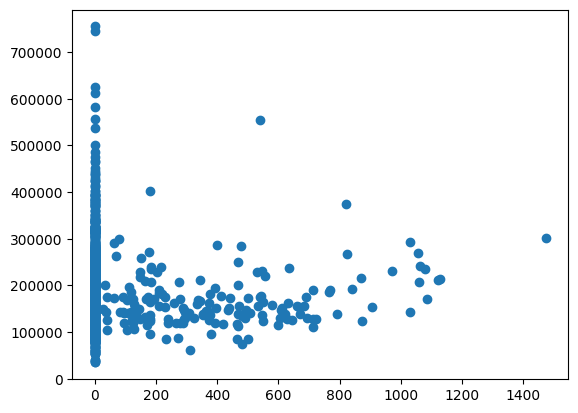

In [29]:
plt.scatter(x = 'BsmtFinSF2' , y = 'SalePrice' , data= train_df)

In [30]:
train_df.query('BsmtFinSF2 > 400  & SalePrice >500000')
#441

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


In [31]:
train_df.query('BsmtFinSF2 > 1400 ')
# 323

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
322,323,60,RL,86.0,10380,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2007,WD,Normal,301000


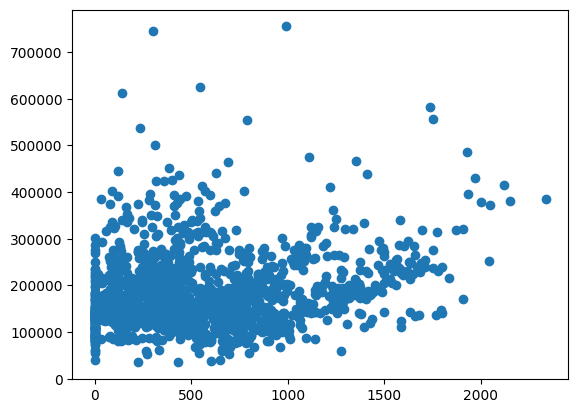

In [32]:
plt.scatter(x = 'BsmtUnfSF' , y = 'SalePrice' , data= train_df)

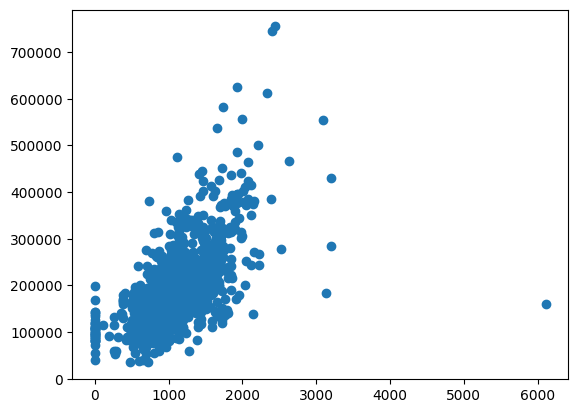

In [33]:
plt.scatter(x = 'TotalBsmtSF' , y = 'SalePrice' , data= train_df)

In [34]:
train_df.query('TotalBsmtSF > 6000 ')
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


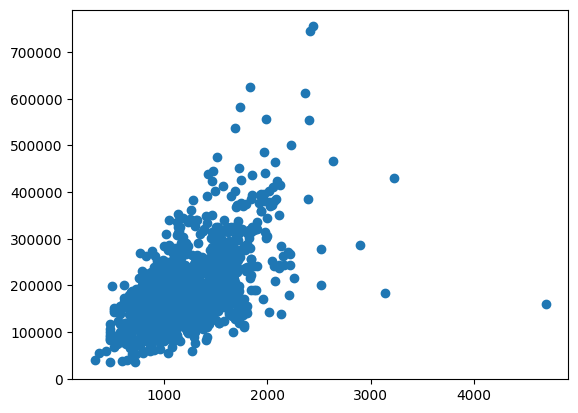

In [35]:
plt.scatter(x = '1stFlrSF' , y = 'SalePrice' , data= train_df)

In [36]:
train_df[train_df['1stFlrSF'] > 4000]
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


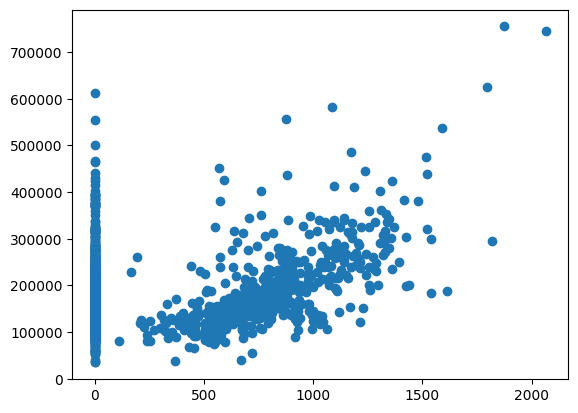

In [37]:
plt.scatter(x = '2ndFlrSF' , y = 'SalePrice' , data= train_df)

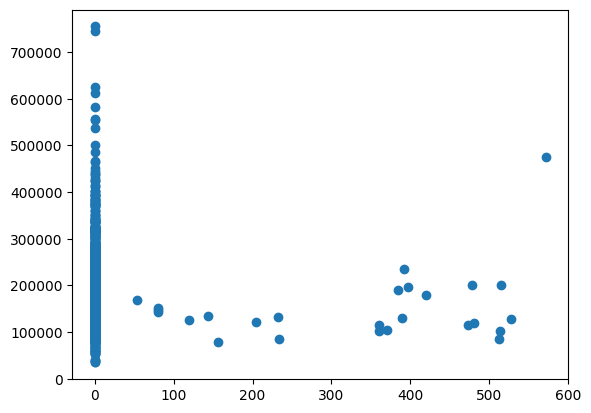

In [38]:
plt.scatter(x = 'LowQualFinSF' , y = 'SalePrice' , data= train_df)

In [39]:
train_df.query('LowQualFinSF > 500 ')
#186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
170,171,50,RM,NaN,12358,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128500
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000
1009,1010,50,RL,60.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,102000


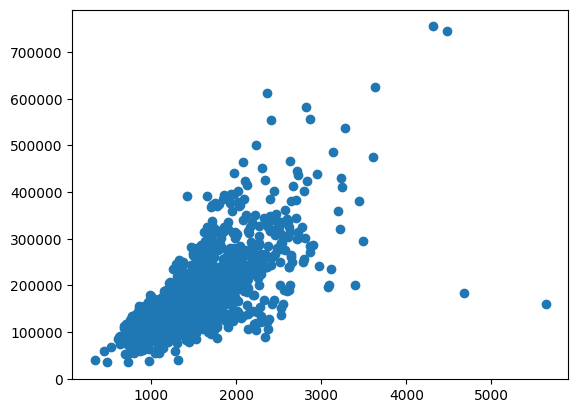

In [40]:
plt.scatter(x = 'GrLivArea' , y = 'SalePrice' , data= train_df)

In [41]:
train_df.query('GrLivArea > 4500 ')
#524 , 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


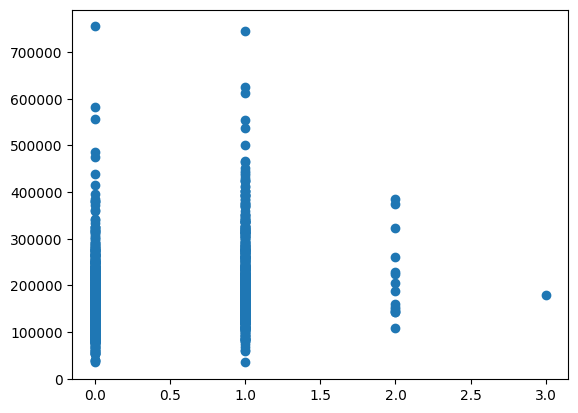

In [42]:
plt.scatter(x = 'BsmtFullBath' , y = 'SalePrice' , data= train_df)

In [43]:
train_df.query('BsmtFullBath == 3 ')
# 739

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


In [44]:
train_df.query('BsmtHalfBath==2 ')
# 598  , 955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


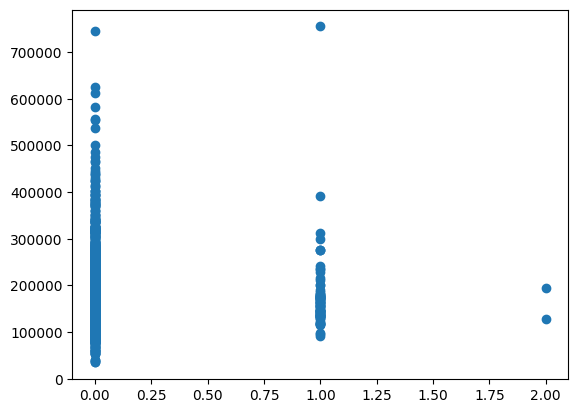

In [45]:
plt.scatter(x = 'BsmtHalfBath' , y = 'SalePrice' , data= train_df)

In [46]:
pd.Series(stats.zscore(train_df['BsmtHalfBath']), index=train_df.index).unique()

array([-0.24106104,  3.94880935,  8.13867973])

In [47]:
train_df.query('(BsmtHalfBath == 1 & SalePrice > 700000) | (BsmtHalfBath == 2)')
#598 , 955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


In [48]:
z = pd.Series(
    stats.zscore(train_df['BsmtHalfBath']),
    index=train_df.index,
    name='BsmtHalfBath_z'
)

# Largest z-scores (highest above average)
z.sort_values(ascending=False).head(10)

597     8.138680
954     8.138680
1405    3.948809
1389    3.948809
1350    3.948809
1335    3.948809
1327    3.948809
1287    3.948809
1276    3.948809
1225    3.948809
Name: BsmtHalfBath_z, dtype: float64

In [49]:
z.sort_values().head(10)

955   -0.241061
966   -0.241061
965   -0.241061
964   -0.241061
963   -0.241061
962   -0.241061
961   -0.241061
960   -0.241061
959   -0.241061
958   -0.241061
Name: BsmtHalfBath_z, dtype: float64

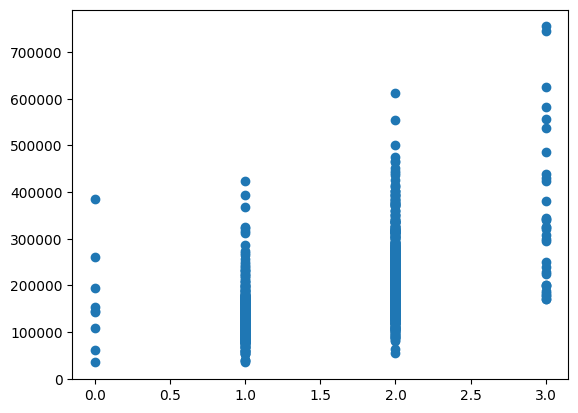

In [50]:
plt.scatter(x = 'FullBath' , y = 'SalePrice' , data= train_df)

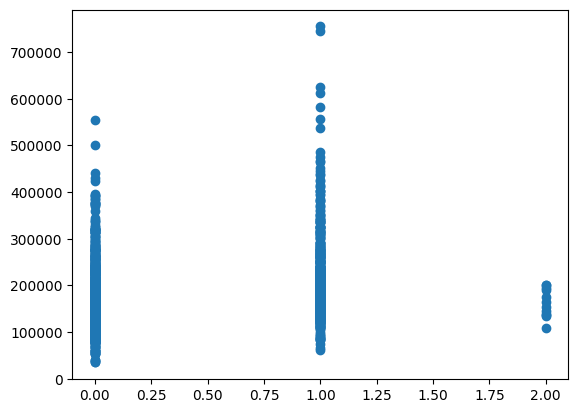

In [51]:
plt.scatter(x = 'HalfBath' , y = 'SalePrice' , data= train_df)

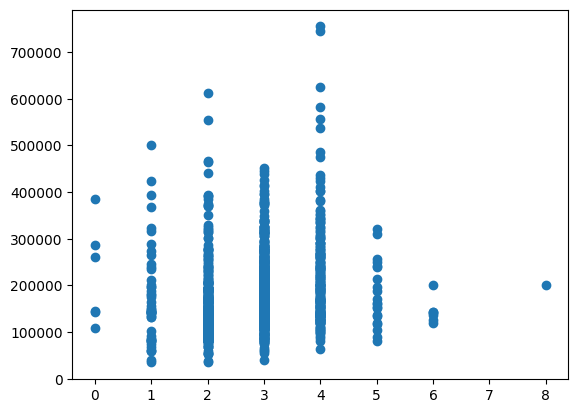

In [52]:
plt.scatter(x = 'BedroomAbvGr' , y = 'SalePrice' , data= train_df)

In [53]:
train_df.query('BedroomAbvGr == 8 ')
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


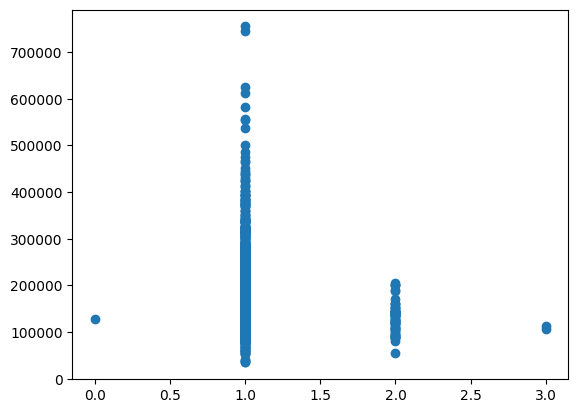

In [54]:
plt.scatter(x = 'KitchenAbvGr' , y = 'SalePrice' , data= train_df)

In [55]:
train_df.query('(KitchenAbvGr == 0 ) | (KitchenAbvGr == 3)')

# 49 , 810 , 955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


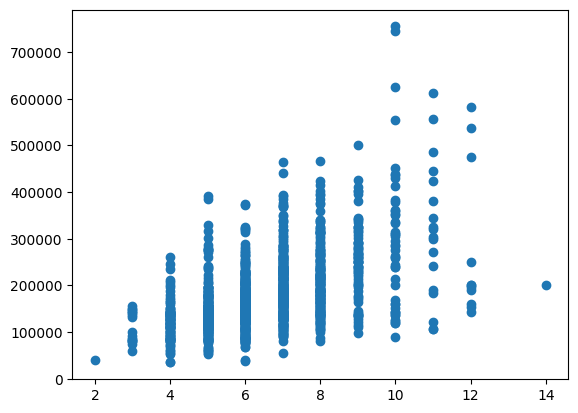

In [56]:
plt.scatter(x = 'TotRmsAbvGrd' , y = 'SalePrice' , data= train_df)

In [57]:
train_df.query('TotRmsAbvGrd == 14 ')
# 636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


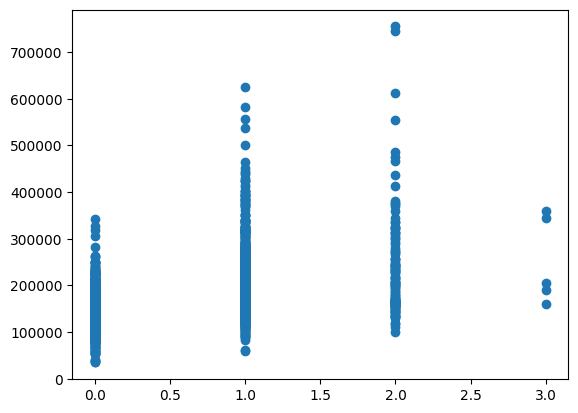

In [58]:
plt.scatter(x = 'Fireplaces' , y = 'SalePrice' , data= train_df)

In [59]:
train_df.query('Fireplaces == 3 ')
# 167 , 310 , 606 , 643 , 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
166,167,20,RL,NaN,10708,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,COD,Normal,190000
309,310,20,RL,90.0,12378,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,360000
605,606,60,RL,85.0,13600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,205000
642,643,80,RL,75.0,13860,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,345000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


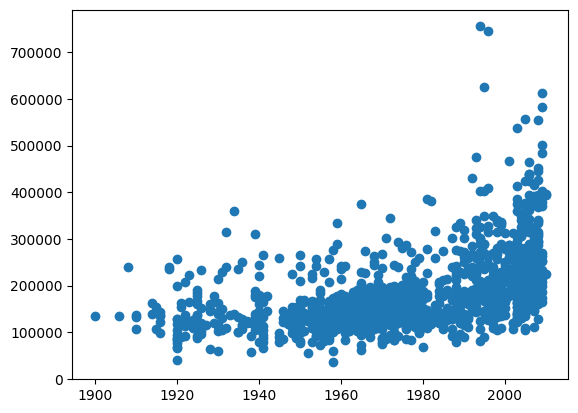

In [60]:
plt.scatter(x = 'GarageYrBlt' , y = 'SalePrice' , data= train_df)

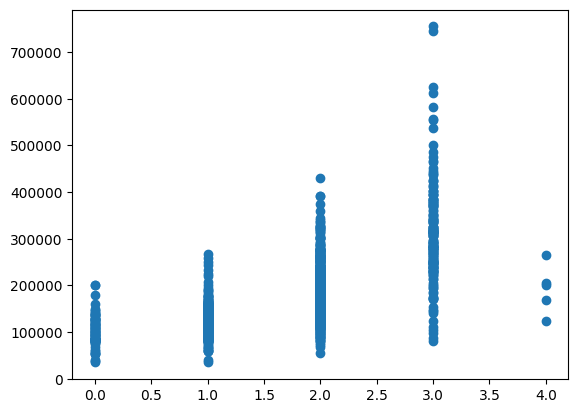

In [61]:
plt.scatter(x = 'GarageCars' , y = 'SalePrice' , data= train_df)

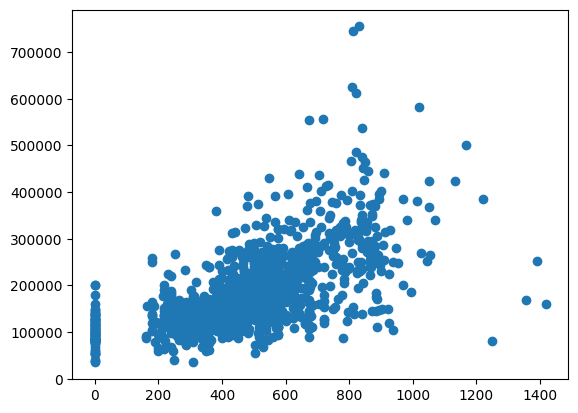

In [62]:
plt.scatter(x = 'GarageArea' , y = 'SalePrice' , data= train_df)

In [63]:
z = pd.Series(
    stats.zscore(train_df['GarageArea']),
    index=train_df.index,
    name='GarageArea_z'
)

# Largest z-scores (highest above average)
z.sort_values(ascending=False).head(10)

1298    4.421526
581     4.290521
1190    4.131443
1061    3.626136
825     3.495131
178     3.242477
664     3.092757
1417    2.788637
270     2.713777
1142    2.709098
Name: GarageArea_z, dtype: float64

In [64]:
z.sort_values().head(10)

1453   -2.212963
1030   -2.212963
1038   -2.212963
48     -2.212963
582    -2.212963
1219   -2.212963
1234   -2.212963
562    -2.212963
620    -2.212963
614    -2.212963
Name: GarageArea_z, dtype: float64

In [65]:
train_df.query('GarageArea >1200 ')
# 582 , 826 , 1062 , 1191 , 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


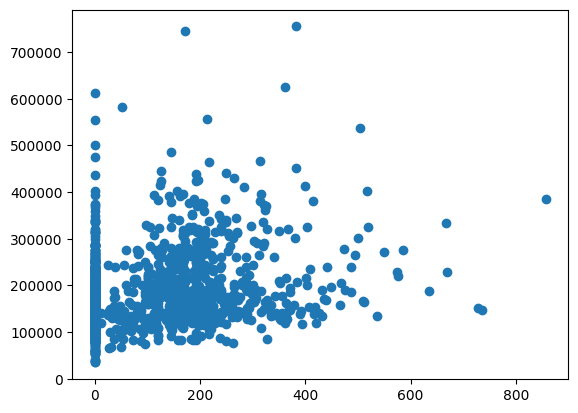

In [66]:
plt.scatter(x = 'WoodDeckSF' , y = 'SalePrice' , data= train_df)

In [67]:
z = pd.Series(
    stats.zscore(train_df['WoodDeckSF']),
    index=train_df.index,
    name='WoodDeckSF_z'
)

# Largest z-scores (highest above average)
z.sort_values(ascending=False).head(10)

53      6.087635
1459    5.121921
1068    5.058072
335     4.595168
1313    4.579205
1210    4.315829
1423    3.924754
64      3.844943
169     3.828981
961     3.637434
Name: WoodDeckSF_z, dtype: float64

In [68]:
train_df.query('WoodDeckSF > 800')
# 54 , 1460 , 1069 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000


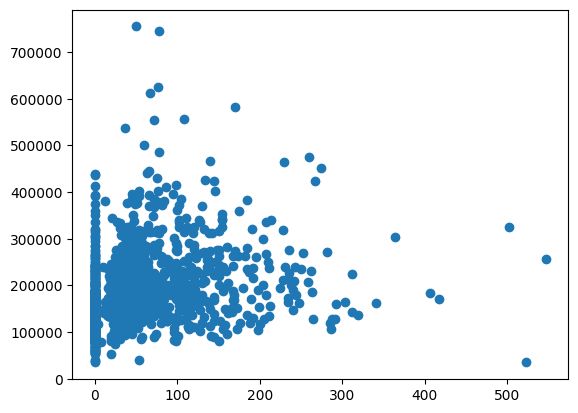

In [69]:
plt.scatter(x = 'OpenPorchSF' , y = 'SalePrice' , data= train_df)

In [70]:
train_df.query('OpenPorchSF > 450')
# 496 , 584 , 1329

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000


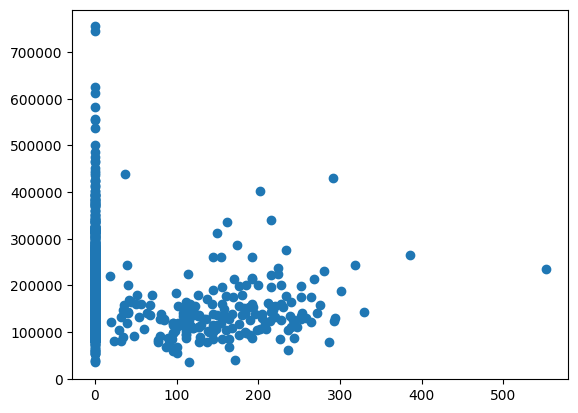

In [71]:
plt.scatter(x = 'EnclosedPorch' , y = 'SalePrice' , data= train_df)

In [72]:
train_df.query('EnclosedPorch > 450')
#198

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


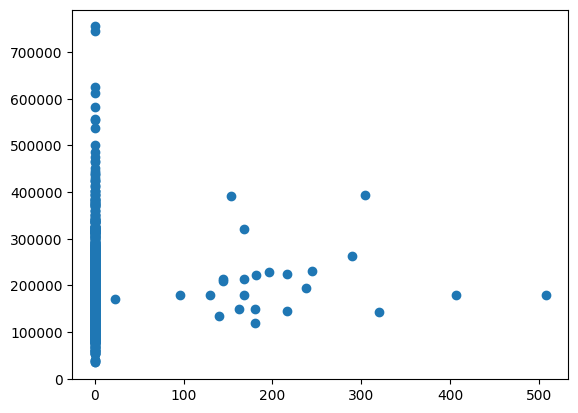

In [73]:
plt.scatter(x = '3SsnPorch' , y = 'SalePrice' , data= train_df)

In [74]:
train_df[train_df['3SsnPorch'] > 300]
# 6, 56 , 206 , 1438

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
55,56,20,RL,100.0,10175,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,180500
205,206,20,RL,99.0,11851,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,180500
1437,1438,20,RL,96.0,12444,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2008,New,Partial,394617


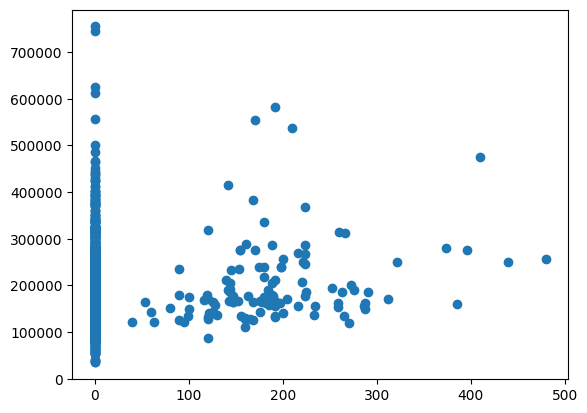

In [75]:
plt.scatter(x = 'ScreenPorch' , y = 'SalePrice' , data= train_df)

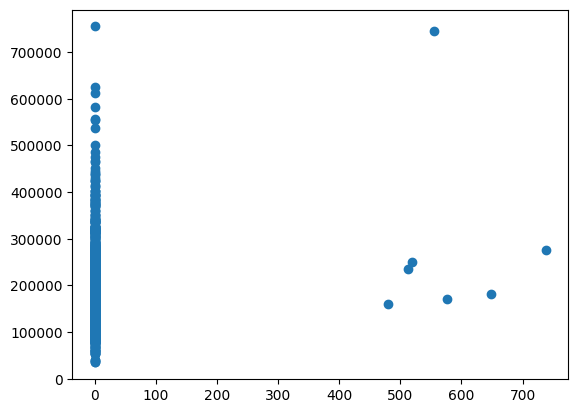

In [76]:
plt.scatter(x = 'PoolArea' , y = 'SalePrice' , data= train_df)

In [77]:
train_df.query('PoolArea > 400')
# 198 , 811 , 1171 , 1183 ,1299 , 1387 , 1424

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000
810,811,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,648,Fa,GdPrv,NaN,0,1,2006,WD,Normal,181000
1170,1171,80,RL,76.0,9880,Pave,NaN,Reg,Lvl,AllPub,...,576,Gd,GdPrv,NaN,0,7,2008,WD,Normal,171000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1386,1387,60,RL,80.0,16692,Pave,NaN,IR1,Lvl,AllPub,...,519,Fa,MnPrv,TenC,2000,7,2006,WD,Normal,250000
1423,1424,80,RL,NaN,19690,Pave,NaN,IR1,Lvl,AllPub,...,738,Gd,GdPrv,NaN,0,8,2006,WD,Alloca,274970


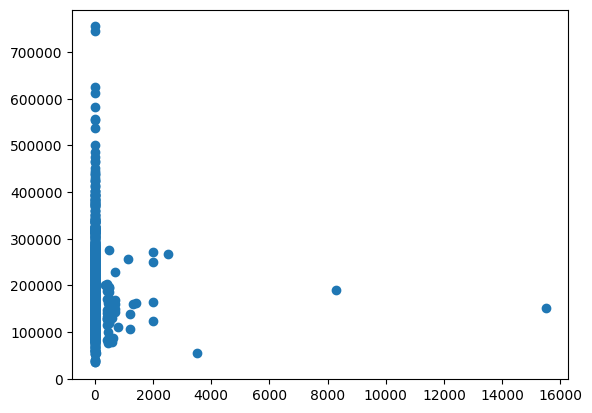

In [78]:
plt.scatter(x = 'MiscVal' , y = 'SalePrice' , data= train_df)

In [79]:
train_df.query('MiscVal > 8000')
# 347 , 1231

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
346,347,20,RL,NaN,12772,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,15500,4,2007,WD,Normal,151500
1230,1231,90,RL,NaN,18890,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,8300,8,2007,WD,Normal,190000


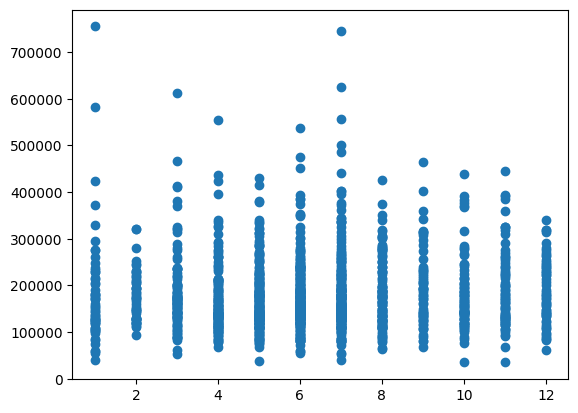

In [80]:
plt.scatter(x = 'MoSold' , y = 'SalePrice' , data= train_df)

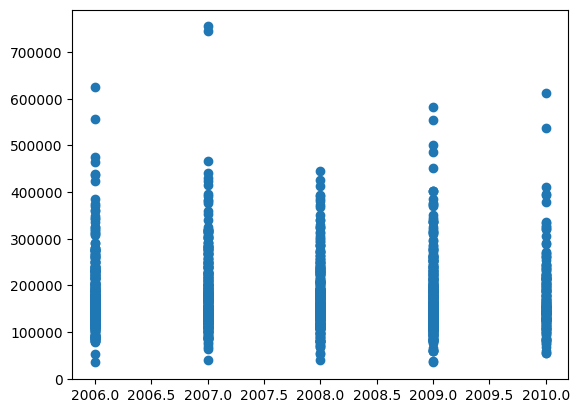

In [81]:
plt.scatter(x = 'YrSold' , y = 'SalePrice' , data= train_df)

In [82]:
train_df.query('YrSold == 2007 & SalePrice > 700000')
# 692 , 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [83]:
Values = [
    6, 49, 54, 56, 167, 186, 198, 206, 250, 298, 310, 314, 323, 336, 347,
    379, 441, 496, 524, 582, 584, 598, 606, 636, 643, 692, 707, 739, 810,
    811, 826, 935, 955, 1062, 1069, 1170, 1171, 1183, 1191, 1231, 1299,
    1329, 1387, 1397, 1424, 1438, 1460
]

In [84]:
train_df = train_df[train_df.Id.isin(Values)== False]

In [85]:
# With dataframe
pd.DataFrame(train_df.isnull().sum().sort_values(ascending = False)).head(20)

,0
PoolQC,1413
MiscFeature,1367
Alley,1325
Fence,1147
MasVnrType,845
FireplaceQu,679
LotFrontage,250
GarageQual,76
GarageFinish,76
GarageType,76


In [86]:
# Without DataFrame
train_df.isnull().sum().sort_values(ascending = False).head(20)

PoolQC          1413
MiscFeature     1367
Alley           1325
Fence           1147
MasVnrType       845
FireplaceQu      679
LotFrontage      250
GarageQual        76
GarageFinish      76
GarageType        76
GarageYrBlt       76
GarageCond        76
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [87]:
train_df['MiscFeature'].unique()

array([nan, 'Shed', 'Othr'], dtype=object)

In [88]:
train_df['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [89]:
train_df['Alley'].fillna('No', inplace = True)
test_df['Alley'].fillna('No', inplace = True)

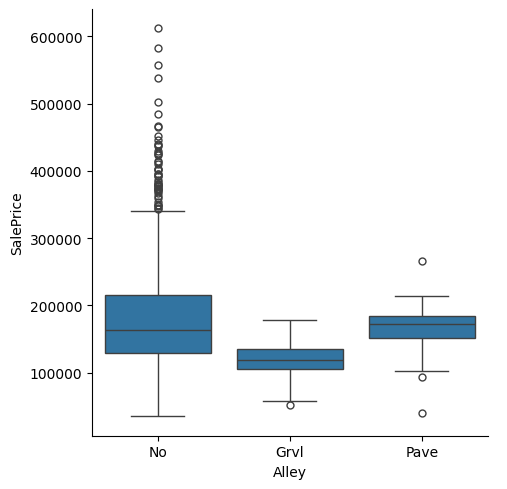

In [90]:
sns.catplot(data=train_df , x= 'Alley' , y = 'SalePrice' , kind = 'box')

In [91]:
train_df.query('Alley== "Grvl"').count()

Id               49
MSSubClass       49
MSZoning         49
LotFrontage      46
LotArea          49
                 ..
MoSold           49
YrSold           49
SaleType         49
SaleCondition    49
SalePrice        49
Length: 81, dtype: int64

In [92]:
train_df['Fence'].unique()

array([nan, 'GdWo', 'GdPrv', 'MnPrv', 'MnWw'], dtype=object)

In [93]:
train_df['Fence'].fillna('No', inplace = True)
test_df['Fence'].fillna('No', inplace = True)

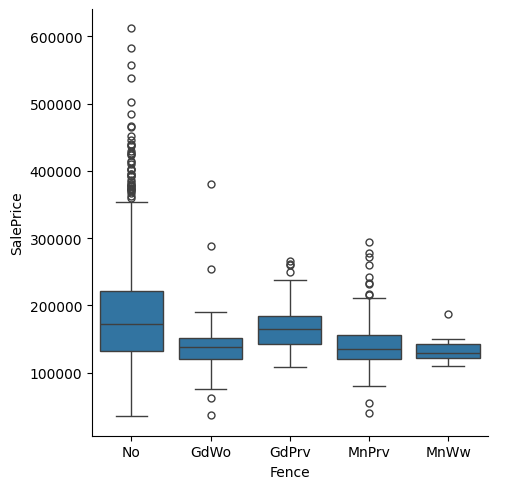

In [94]:
sns.catplot(data=train_df , x= 'Fence' , y = 'SalePrice' , kind = 'box')

In [95]:
train_df['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [96]:
train_df['MasVnrType'].fillna('No', inplace = True)
test_df['MasVnrType'].fillna('No', inplace = True)

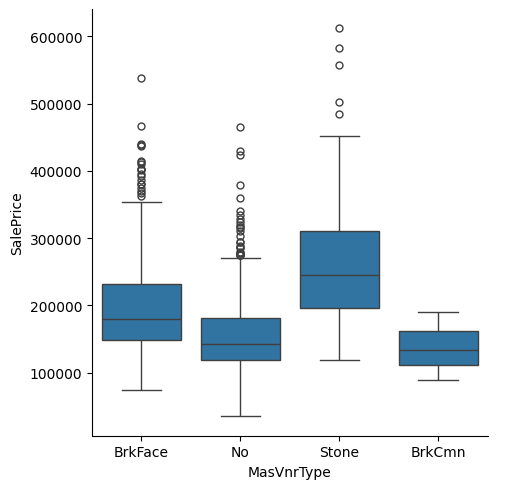

In [97]:
sns.catplot(data=train_df , x= 'MasVnrType' , y = 'SalePrice' , kind = 'box')

In [98]:
train_df['MasVnrArea'].fillna(0, inplace = True)
test_df['MasVnrArea'].fillna(0, inplace = True)

In [99]:
train_df['MasVnrArea'].replace('no', 0, inplace=True)
test_df['MasVnrArea'].replace('no', 0, inplace=True)

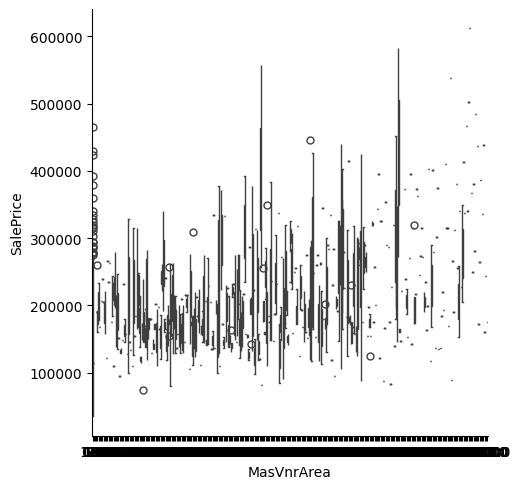

In [100]:
sns.catplot(data=train_df , x= 'MasVnrArea' , y = 'SalePrice' , kind = 'box')

In [101]:
train_df['MasVnrArea'].unique()

array([1.960e+02, 0.000e+00, 1.620e+02, 3.500e+02, 1.860e+02, 2.400e+02,
       2.860e+02, 3.060e+02, 2.120e+02, 1.800e+02, 3.800e+02, 2.810e+02,
       6.400e+02, 2.000e+02, 2.460e+02, 1.320e+02, 6.500e+02, 1.010e+02,
       4.120e+02, 4.560e+02, 1.031e+03, 1.780e+02, 5.730e+02, 3.440e+02,
       2.870e+02, 1.670e+02, 1.115e+03, 4.000e+01, 1.040e+02, 5.760e+02,
       4.430e+02, 4.680e+02, 6.600e+01, 2.200e+01, 2.840e+02, 7.600e+01,
       2.030e+02, 6.800e+01, 1.830e+02, 4.800e+01, 2.800e+01, 3.360e+02,
       6.000e+02, 7.680e+02, 4.800e+02, 2.200e+02, 1.840e+02, 1.129e+03,
       1.160e+02, 1.350e+02, 2.660e+02, 8.500e+01, 3.090e+02, 1.360e+02,
       2.880e+02, 7.000e+01, 3.200e+02, 5.000e+01, 1.200e+02, 4.360e+02,
       2.520e+02, 8.400e+01, 6.640e+02, 2.260e+02, 3.000e+02, 6.530e+02,
       1.120e+02, 4.910e+02, 2.680e+02, 7.480e+02, 9.800e+01, 2.750e+02,
       1.380e+02, 2.050e+02, 2.620e+02, 1.280e+02, 2.600e+02, 1.530e+02,
       6.400e+01, 3.120e+02, 1.600e+01, 9.220e+02, 

In [102]:
# 1. Replace the string 'No' with 0
train_df['MasVnrArea'].replace('No', 0, inplace=True)
test_df['MasVnrArea'].replace('No', 0, inplace=True)

# 2. Convert the whole column to numeric
train_df['MasVnrArea'] = pd.to_numeric(train_df['MasVnrArea'])
test_df['MasVnrArea']  = pd.to_numeric(test_df['MasVnrArea'])

In [103]:
train_df['MasVnrArea'].unique()

array([1.960e+02, 0.000e+00, 1.620e+02, 3.500e+02, 1.860e+02, 2.400e+02,
       2.860e+02, 3.060e+02, 2.120e+02, 1.800e+02, 3.800e+02, 2.810e+02,
       6.400e+02, 2.000e+02, 2.460e+02, 1.320e+02, 6.500e+02, 1.010e+02,
       4.120e+02, 4.560e+02, 1.031e+03, 1.780e+02, 5.730e+02, 3.440e+02,
       2.870e+02, 1.670e+02, 1.115e+03, 4.000e+01, 1.040e+02, 5.760e+02,
       4.430e+02, 4.680e+02, 6.600e+01, 2.200e+01, 2.840e+02, 7.600e+01,
       2.030e+02, 6.800e+01, 1.830e+02, 4.800e+01, 2.800e+01, 3.360e+02,
       6.000e+02, 7.680e+02, 4.800e+02, 2.200e+02, 1.840e+02, 1.129e+03,
       1.160e+02, 1.350e+02, 2.660e+02, 8.500e+01, 3.090e+02, 1.360e+02,
       2.880e+02, 7.000e+01, 3.200e+02, 5.000e+01, 1.200e+02, 4.360e+02,
       2.520e+02, 8.400e+01, 6.640e+02, 2.260e+02, 3.000e+02, 6.530e+02,
       1.120e+02, 4.910e+02, 2.680e+02, 7.480e+02, 9.800e+01, 2.750e+02,
       1.380e+02, 2.050e+02, 2.620e+02, 1.280e+02, 2.600e+02, 1.530e+02,
       6.400e+01, 3.120e+02, 1.600e+01, 9.220e+02, 

In [104]:
train_df['MasVnrArea'] = train_df['MasVnrArea'].astype('Int64')

In [105]:
train_df['MasVnrArea'].unique()

<IntegerArray>
[196,   0, 162, 350, 186, 240, 286, 306, 212, 180,
 ...
 366, 731, 448, 294, 310, 237,  96, 438, 194, 119]
Length: 320, dtype: Int64

In [106]:
train_df['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [107]:
train_df['FireplaceQu'].fillna('No', inplace = True)
test_df['FireplaceQu'].fillna('No', inplace = True)

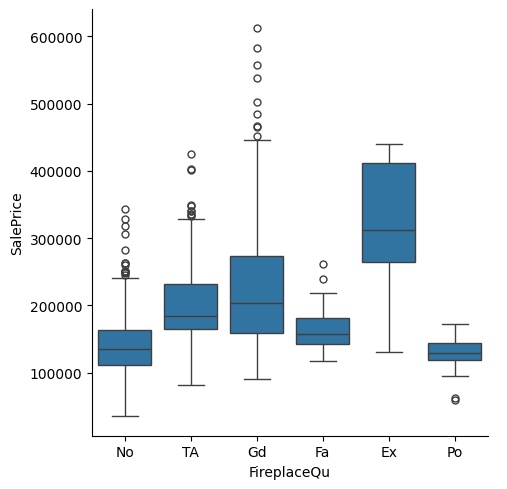

In [108]:
sns.catplot(data=train_df , x= 'FireplaceQu' , y = 'SalePrice' , kind = 'box')

In [109]:
train_df['LotFrontage'].fillna(0, inplace = True)
test_df['LotFrontage'].fillna(0, inplace = True)

In [110]:
a = train_df['GarageYrBlt'].corr(train_df['YearBuilt'])*100
c = float(a)
print(c)

82.99084614680582


In [111]:
train_df['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [112]:
train_df['GarageCond'].fillna('No', inplace = True)
test_df['GarageCond'].fillna('No', inplace = True)

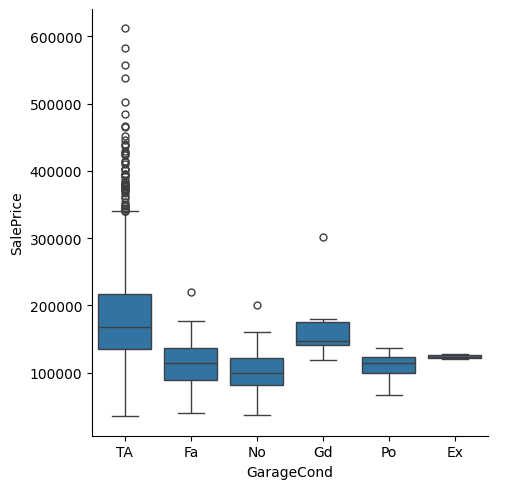

In [113]:
sns.catplot(data=train_df , x= 'GarageCond' , y = 'SalePrice' , kind = 'box')

In [114]:
train_df['GarageType'].fillna('No', inplace = True)
test_df['GarageType'].fillna('No', inplace = True)

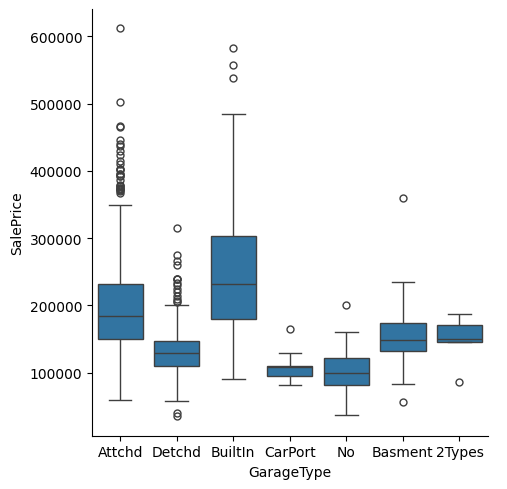

In [115]:
sns.catplot(data=train_df , x= 'GarageType' , y = 'SalePrice' , kind = 'box')

In [116]:
train_df['GarageFinish'].fillna('No', inplace = True)
test_df['GarageFinish'].fillna('No', inplace = True)

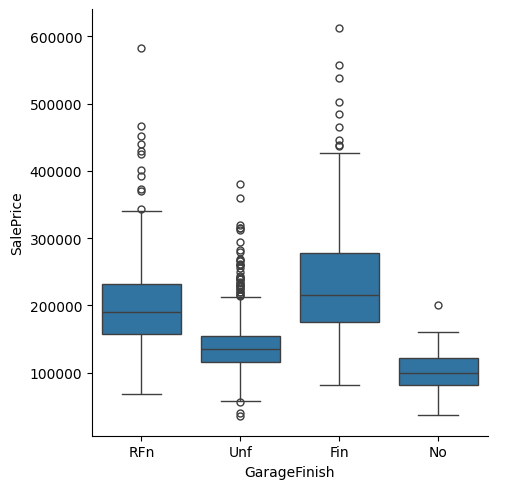

In [117]:
sns.catplot(data=train_df , x= 'GarageFinish' , y = 'SalePrice' , kind = 'box')

In [118]:
train_df['GarageQual'].fillna('No', inplace = True)
test_df['GarageQual'].fillna('No', inplace = True)

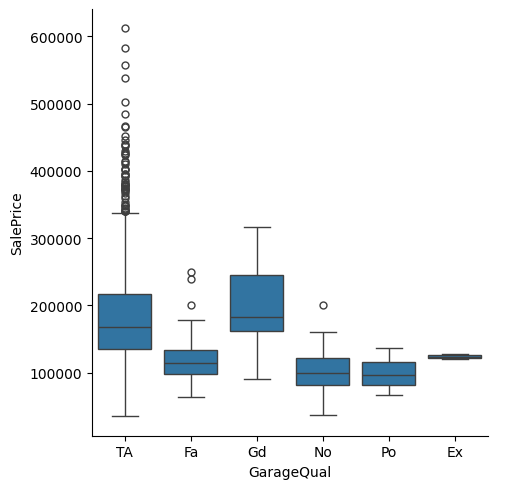

In [119]:
sns.catplot(data=train_df , x= 'GarageQual' , y = 'SalePrice' , kind = 'box')

In [120]:
train_df['BsmtFinType2'].unique()

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [121]:
train_df['BsmtFinType2'].fillna('Unf', inplace = True)
test_df['BsmtFinType2'].fillna('Unf', inplace = True)

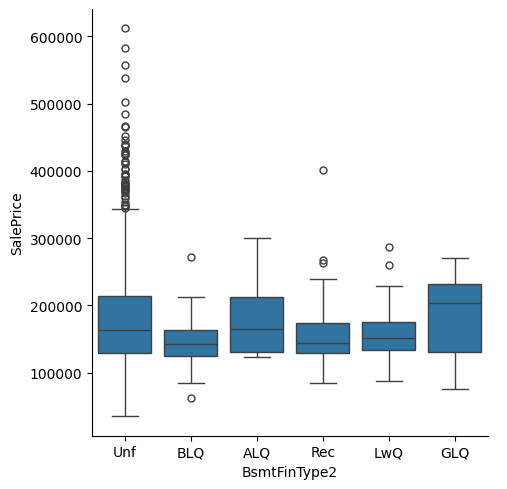

In [122]:
sns.catplot(data = train_df, x = 'BsmtFinType2', y  = 'SalePrice' , kind = 'box')

In [123]:
train_df['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [124]:
train_df['BsmtExposure'].fillna('NA', inplace = True)
test_df['BsmtExposure'].fillna('NA', inplace = True)

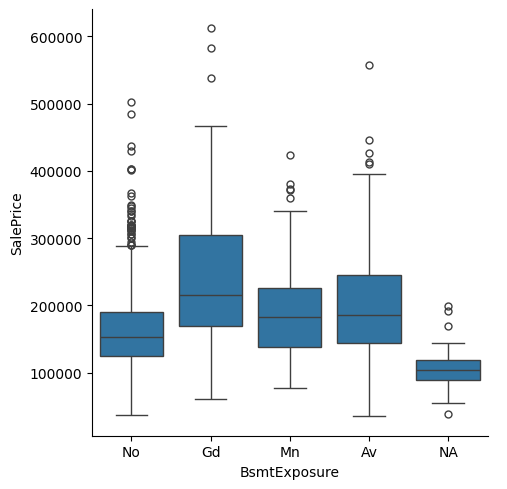

In [125]:
sns.catplot(data = train_df, x = 'BsmtExposure', y  = 'SalePrice' , kind = 'box')

In [126]:
train_df['BsmtCond'].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [127]:
train_df['BsmtCond'].fillna('NA', inplace = True)
test_df['BsmtCond'].fillna('NA', inplace = True)

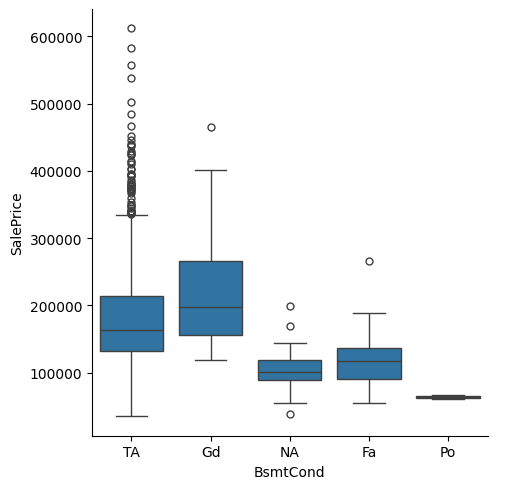

In [128]:
sns.catplot(data = train_df, x = 'BsmtCond', y  = 'SalePrice' , kind = 'box')

In [129]:
train_df['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [130]:
train_df['BsmtQual'].fillna('NA', inplace = True)
test_df['BsmtQual'].fillna('NA', inplace = True)

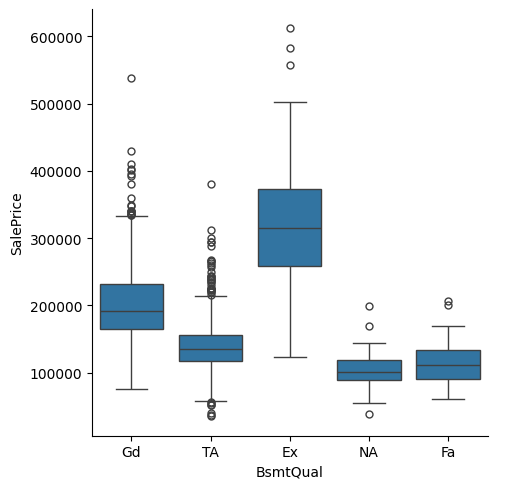

In [131]:
sns.catplot(data = train_df, x = 'BsmtQual', y  = 'SalePrice' , kind = 'box')

In [132]:
train_df['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [133]:
train_df['BsmtFinType1'].fillna('NA', inplace = True)
test_df['BsmtFinType1'].fillna('NA', inplace = True)

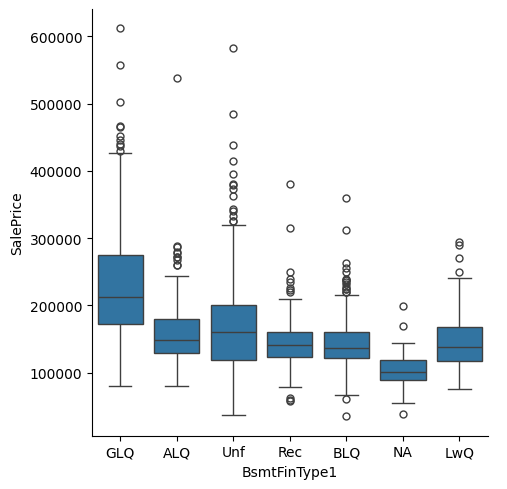

In [134]:
sns.catplot(data = train_df, x = 'BsmtFinType1', y  = 'SalePrice' , kind = 'box')

In [135]:
train_df['MasVnrArea'].unique()

<IntegerArray>
[196,   0, 162, 350, 186, 240, 286, 306, 212, 180,
 ...
 366, 731, 448, 294, 310, 237,  96, 438, 194, 119]
Length: 320, dtype: Int64

In [136]:
train_df['MasVnrArea'].fillna(0, inplace = True)
test_df['MasVnrArea'].fillna(0, inplace = True)

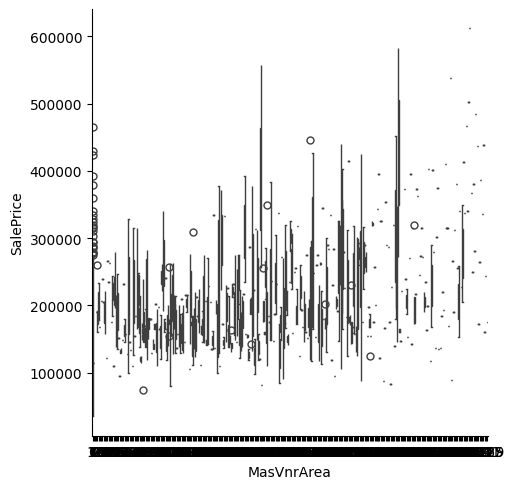

In [137]:
sns.catplot(data = train_df, x = 'MasVnrArea', y  = 'SalePrice' , kind = 'box')

In [138]:
train_df['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [139]:
train_df['Electrical'].fillna('SBrkr', inplace = True)
test_df['Electrical'].fillna('SBrkr', inplace = True)

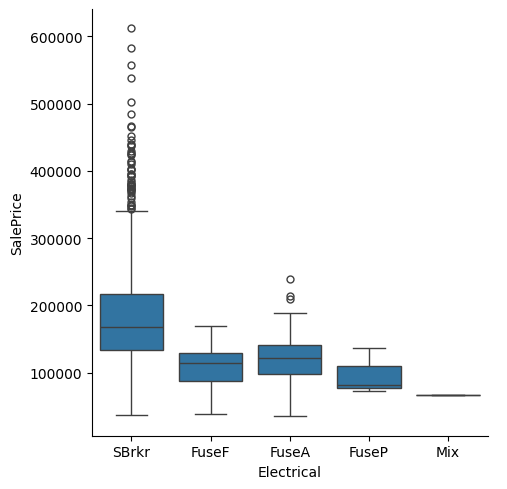

In [140]:
sns.catplot(data = train_df, x = 'Electrical', y  = 'SalePrice' , kind = 'box')

In [141]:
train_df = train_df.drop(columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence',  'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])
test_df = test_df.drop(columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence',  'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])

In [142]:
# step 3 Feature Engineering

In [143]:
train_df['houseage'] = train_df['YrSold'] - train_df['YearBuilt']
test_df['houseage'] = test_df['YrSold'] - test_df['YearBuilt']

In [144]:
train_df['houseremodelage'] = train_df['YrSold'] - train_df['YearRemodAdd']
test_df['houseremodelage'] = test_df['YrSold'] - test_df['YearRemodAdd']

In [145]:
train_df['totalsf'] = train_df['1stFlrSF'] + train_df['2ndFlrSF']  + train_df['BsmtFinSF1'] + train_df['BsmtFinSF2']
test_df['totalsf'] = test_df['1stFlrSF'] + test_df['2ndFlrSF']  + test_df['BsmtFinSF1'] + test_df['BsmtFinSF2']

In [146]:
train_df['totalarea'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']
test_df['totalarea'] = test_df['GrLivArea'] + test_df['TotalBsmtSF']

In [147]:
train_df['totalbaths'] = train_df['BsmtFullBath'] + train_df['FullBath'] + 0.5 * (train_df['BsmtHalfBath']+ train_df['HalfBath'])
test_df['totalbaths'] = test_df['BsmtFullBath'] + test_df['FullBath'] + 0.5 * (test_df['BsmtHalfBath']+ test_df['HalfBath'])

In [148]:
train_df['totalporchsf'] = train_df['OpenPorchSF'] + train_df['3SsnPorch'] + train_df['EnclosedPorch'] + train_df['ScreenPorch'] + train_df['WoodDeckSF']
test_df['totalporchsf'] = test_df['OpenPorchSF'] + test_df['3SsnPorch'] + test_df['EnclosedPorch'] + test_df['ScreenPorch'] + test_df['WoodDeckSF']

In [149]:
train_df = train_df.drop(columns=['Id','YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF',])
test_df = test_df.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])

In [150]:
train_df = train_df.drop(columns=['PoolArea'])
test_df = test_df.drop(columns=['PoolArea'])

<Axes: >

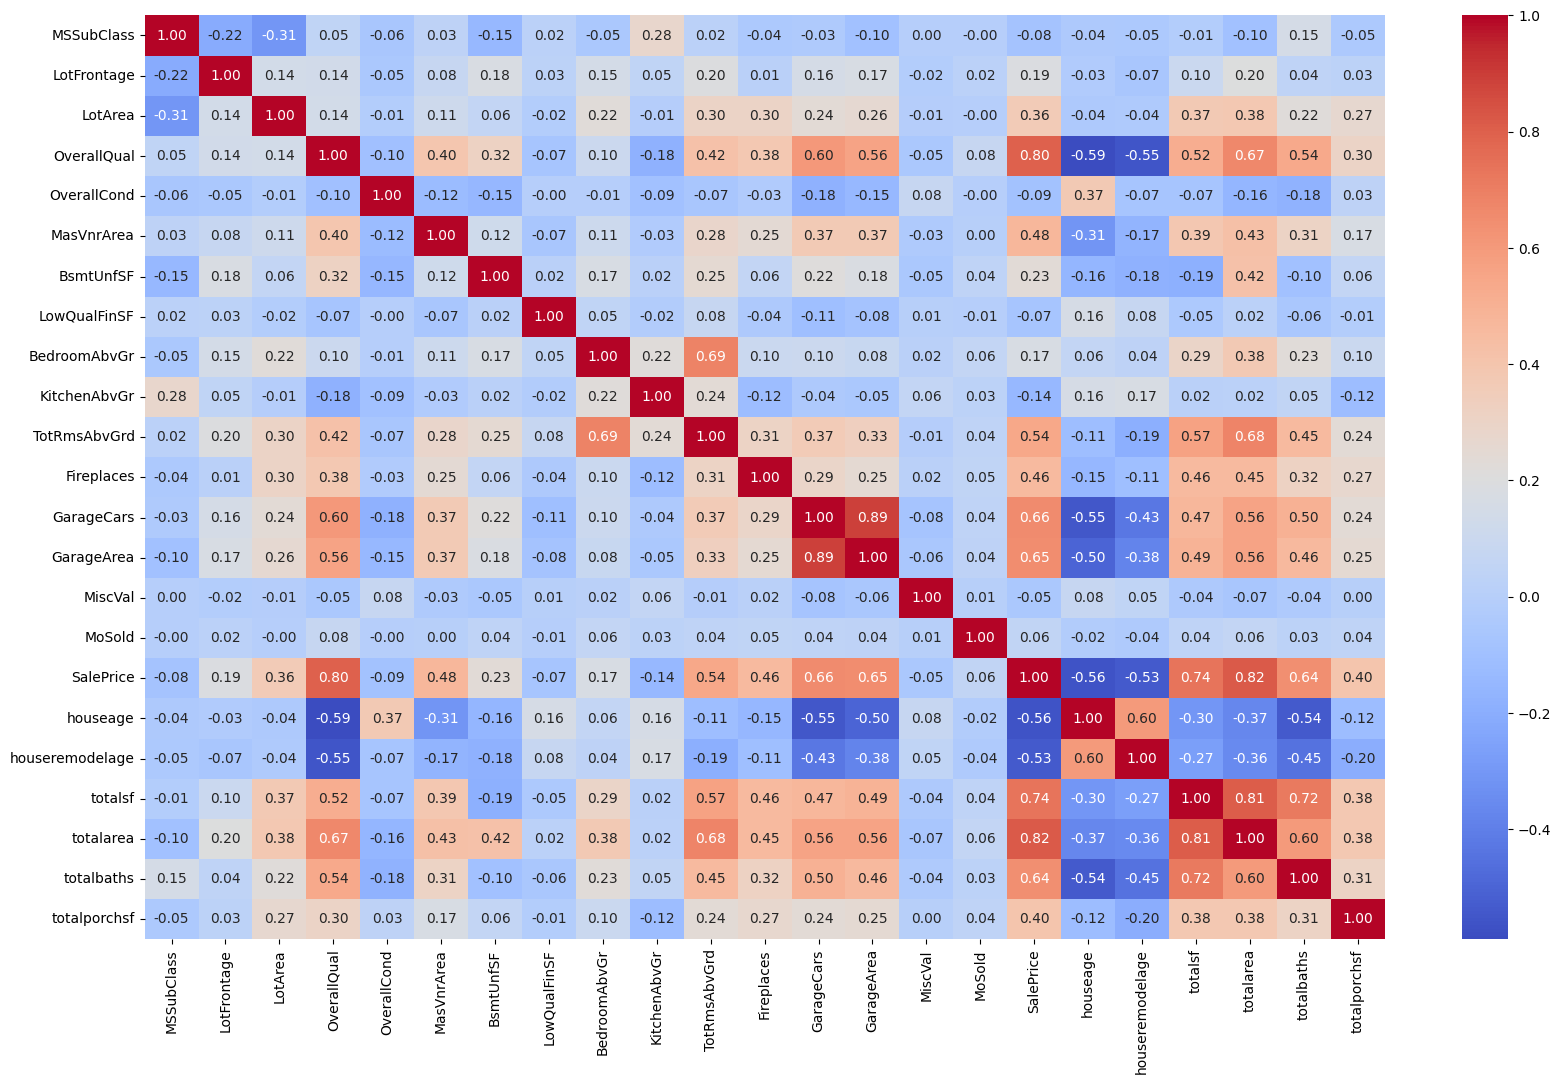

In [151]:
correlation_matrix = train_df.corr(numeric_only=True).fillna(0)
plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [152]:
train_df = train_df.drop(columns=['GarageCars'])
test_df = test_df.drop(columns=['GarageCars'])

In [153]:
train_df = train_df.drop(columns=['MiscVal' , 'MoSold',])
test_df = test_df.drop(columns=['MiscVal' , 'MoSold',])

<Axes: xlabel='SalePrice', ylabel='Count'>

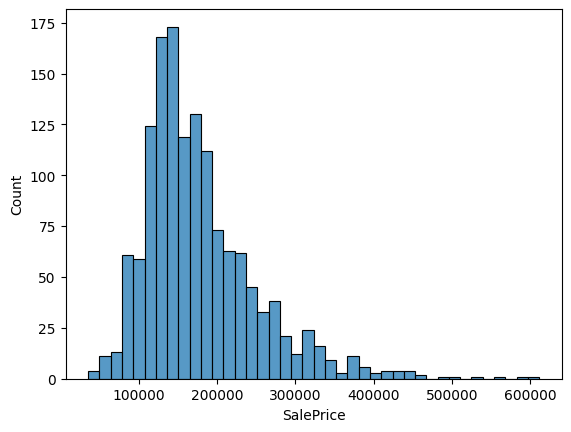

In [154]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

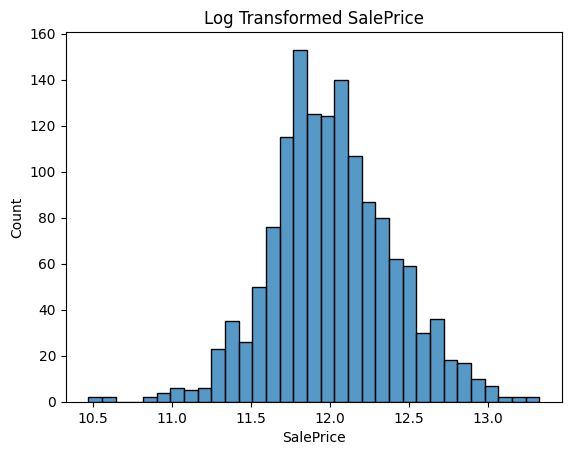

In [155]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
sns.histplot(train_df['SalePrice'])
plt.title('Log Transformed SalePrice')
plt.show()

In [156]:
train_df.dtypes[train_df.dtypes=='object']

MSZoning         object
Street           object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
PavedDrive       object
SaleType         object
SaleCondition    object
dtype: object

In [157]:
train_df.dtypes[train_df.dtypes !='object']

MSSubClass           int64
LotFrontage        float64
LotArea              int64
OverallQual          int64
OverallCond          int64
MasVnrArea           Int64
BsmtUnfSF            int64
LowQualFinSF         int64
BedroomAbvGr         int64
KitchenAbvGr         int64
TotRmsAbvGrd         int64
Fireplaces           int64
GarageArea           int64
SalePrice          float64
houseage             int64
houseremodelage      int64
totalsf              int64
totalarea            int64
totalbaths         float64
totalporchsf         int64
dtype: object

In [158]:
ode_cols = ['LotShape', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
            'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'CentralAir',
            'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish',
            'GarageQual', 'PavedDrive', 'Electrical']

In [159]:
ohe_cols = ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
            'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
            'GarageType', 'SaleType', 'SaleCondition']

In [160]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')

In [161]:
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [162]:
ode_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [163]:
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [164]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols),
    ('ode_p', ode_pipeline, ode_cols),
    ('ohe_p', ohe_pipeline, ohe_cols),
    ],
    remainder='passthrough', 
    n_jobs=-1)

In [165]:
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])

In [166]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

In [167]:
X_preprocessed = pipeline.fit_transform(X)

In [168]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

In [169]:
# building models

In [170]:
lr = LinearRegression()

In [171]:
lr.fit(X_train, y_train)

LinearRegression()

In [172]:
y_pred_lr = lr.predict(X_test)

In [173]:
mean_squared_error(y_test, y_pred_lr)

0.018277301879909266

In [174]:
print(train_df.select_dtypes(include='object').columns.tolist())

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'PavedDrive', 'SaleType', 'SaleCondition']


In [175]:
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

Series([], dtype: int64)


In [176]:
print("MSE: ", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:  ", r2_score(y_test, y_pred_lr))

MSE:  0.018277301879909266
RMSE: 0.1351935718882716
R2:   0.8893368222724134


In [177]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("R2:  ", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R2:   0.8971684860526977
RMSE: 0.1303219557735639


In [178]:
params = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 15, 25, 50, 100, 200, 500]}

grid_ridge = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

print("Best alpha:", grid_ridge.best_params_)
print("Best CV R2:", round(grid_ridge.best_score_, 4))

y_pred_ridge_tuned = grid_ridge.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_ridge_tuned), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_ridge_tuned)), 4))

Best alpha: {'alpha': 15}
Best CV R2: 0.917
Test R2:   0.9056
Test RMSE: 0.1248


In [179]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("R2:  ", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

R2:   0.9067200499518062
RMSE: 0.1241219604468957


In [180]:
params = {'alpha': [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003]}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), params, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)

print("Best alpha:", grid_lasso.best_params_)
print("Best CV R2:", round(grid_lasso.best_score_, 4))

y_pred_lasso_tuned = grid_lasso.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_lasso_tuned), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lasso_tuned)), 4))

zero_features = np.sum(grid_lasso.best_estimator_.coef_ == 0)
print(f"Features removed by Lasso: {zero_features}")

Best alpha: {'alpha': 0.0005}
Best CV R2: 0.9171
Test R2:   0.9075
Test RMSE: 0.1236
Features removed by Lasso: 115


In [181]:
coef_df = pd.DataFrame({
    'Feature': range(len(grid_lasso.best_estimator_.coef_)),
    'Coefficient': grid_lasso.best_estimator_.coef_
})

kept = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', ascending=False)
print(f"Features kept: {len(kept)}")
print(kept.to_string(index=False))

Features kept: 75
 Feature  Coefficient
      62     0.104327
      16     0.092470
      78     0.073356
       3     0.060084
     124     0.059583
      15     0.054379
      27     0.052110
       4     0.050068
      72     0.040411
      36     0.035322
      83     0.030861
      12     0.030480
      59     0.029501
      77     0.028681
      38     0.027544
     189     0.027468
       2     0.027024
      21     0.024052
     188     0.023644
      29     0.023610
     155     0.021699
      11     0.020763
      10     0.019329
      60     0.018036
      17     0.017501
      33     0.017269
      49     0.016983
      43     0.015538
      18     0.015271
     129     0.015118
     169     0.012000
     149     0.010293
     100     0.009890
     159     0.005972
     107     0.005675
      32     0.004500
       5     0.001730
     133     0.001571
       1     0.001547
      23     0.001442
     171     0.000771
      19     0.000144
      30    -0.000119
      67    -0

In [182]:
params = {
    'alpha'    : [0.0001, 0.0005, 0.001, 0.005, 0.01],
    'l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9]
}

eln = ElasticNet(max_iter=10000)

grid_en = GridSearchCV(eln, params, cv=5, scoring='r2')
grid_en.fit(X_train, y_train)

print("Best params:", grid_en.best_params_)
print("Best CV R2:", round(grid_en.best_score_, 4))

y_pred_en = grid_en.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_en), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_en)), 4))

Best params: {'alpha': 0.001, 'l1_ratio': 0.3}
Best CV R2: 0.9173
Test R2:   0.9063
Test RMSE: 0.1244


In [183]:
params = {
    'alpha'  : [0.01, 0.1, 1, 5, 10],
    'kernel' : ['linear', 'rbf', 'polynomial']
}

kr = KernelRidge()

grid_kr = GridSearchCV(kr, params, cv=5, scoring='r2')
grid_kr.fit(X_train, y_train)

print("Best params:", grid_kr.best_params_)
print("Best CV R2:", round(grid_kr.best_score_, 4))

y_pred_kr = grid_kr.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_kr), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_kr)), 4))

Best params: {'alpha': 0.1, 'kernel': 'polynomial'}
Best CV R2: 0.873
Test R2:   0.8407
Test RMSE: 0.1622


In [184]:
params = {
    'n_estimators'     : [300, 500],
    'max_depth'        : [15, 20, 25, None],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 0.3, 0.5]
}

rf = RandomForestRegressor(random_state=25)

grid_rf = GridSearchCV(rf, params, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV R2:", round(grid_rf.best_score_, 4))

y_pred_rf = grid_rf.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_rf), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))

Best params: {'max_depth': None, 'max_features': 0.3, 'min_samples_split': 2, 'n_estimators': 500}
Best CV R2: 0.8957
Test R2:   0.8922
Test RMSE: 0.1334


In [185]:
params = {
    'n_estimators' : [100, 200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 4, 5],
    'subsample'    : [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=25)

grid_gb = GridSearchCV(gb, params, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print("Best params:", grid_gb.best_params_)
print("Best CV R2:", round(grid_gb.best_score_, 4))

y_pred_gb = grid_gb.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_gb), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_gb)), 4))

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best CV R2: 0.9149
Test R2:   0.8993
Test RMSE: 0.129


In [186]:
params = {
    'n_estimators'    : [300, 500],
    'learning_rate'   : [0.01, 0.05],
    'max_depth'       : [3, 4, 5],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha'       : [0, 0.1],
    'reg_lambda'      : [1, 1.5]
}

xgb = XGBRegressor(random_state=25)

grid_xgb = GridSearchCV(xgb, params, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best CV R2:", round(grid_xgb.best_score_, 4))

y_pred_xgb = grid_xgb.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_xgb), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4))

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}
Best CV R2: 0.9192
Test R2:   0.9057
Test RMSE: 0.1248


In [187]:
params = {
    'n_estimators'    : [500, 700, 1000],
    'learning_rate'   : [0.01, 0.05],
    'max_depth'       : [3],
    'subsample'       : [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'reg_alpha'       : [0.1, 0.2],
    'reg_lambda'      : [1]
}

xgb = XGBRegressor(random_state=25)

grid_xgb = GridSearchCV(xgb, params, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best CV R2:", round(grid_xgb.best_score_, 4))

y_pred_xgb = grid_xgb.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_xgb), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4))

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}
Best CV R2: 0.9194
Test R2:   0.9062
Test RMSE: 0.1245


In [188]:
params = {
    'iterations'        : [300, 500, 700],
    'learning_rate'     : [0.01, 0.05],
    'depth'             : [4, 6, 8],
    'l2_leaf_reg'       : [1, 3, 5],
    'bagging_temperature': [0.5, 1.0]
}

cat = CatBoostRegressor(random_state=25, verbose=0)

grid_cat = GridSearchCV(cat, params, cv=5, scoring='r2', n_jobs=-1)
grid_cat.fit(X_train, y_train)

print("Best params:", grid_cat.best_params_)
print("Best CV R2:", round(grid_cat.best_score_, 4))

y_pred_cat = grid_cat.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_cat), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_cat)), 4))

Best params: {'bagging_temperature': 0.5, 'depth': 4, 'iterations': 700, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Best CV R2: 0.9186
Test R2:   0.9081
Test RMSE: 0.1232


In [189]:
import warnings
warnings.filterwarnings('ignore')

params = {
    'n_estimators'    : [300, 500, 700],
    'learning_rate'   : [0.01, 0.05],
    'max_depth'       : [4, 6],
    'num_leaves'      : [15, 31, 50],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

lgbm = lgb.LGBMRegressor(random_state=25, verbose=-1)

grid_lgbm = GridSearchCV(lgbm, params, cv=5, scoring='r2', n_jobs=-1)
grid_lgbm.fit(X_train, y_train)

print("Best params:", grid_lgbm.best_params_)
print("Best CV R2:", round(grid_lgbm.best_score_, 4))

y_pred_lgbm = grid_lgbm.predict(X_test)
print("Test R2:  ", round(r2_score(y_test, y_pred_lgbm), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lgbm)), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 700, 'num_leaves': 15, 'subsample': 0.7}
Best CV R2: 0.9131
Test R2:   0.8991
Test RMSE: 0.1291


In [190]:
voting = VotingRegressor(estimators=[
    ('lasso',    grid_lasso.best_estimator_),
    ('elasticnet', grid_en.best_estimator_),
    ('catboost', grid_cat.best_estimator_),
    ('xgb',      grid_xgb.best_estimator_),
    ('gb',       grid_gb.best_estimator_)
])

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

print("Test R2:  ", round(r2_score(y_test, y_pred_voting), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_voting)), 4))

Test R2:   0.9123
Test RMSE: 0.1203


In [191]:
estimators = [
    ('lasso',      grid_lasso.best_estimator_),
    ('elasticnet', grid_en.best_estimator_),
    ('catboost',   grid_cat.best_estimator_),
    ('xgb',        grid_xgb.best_estimator_),
    ('gb',         grid_gb.best_estimator_)
]

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)

print("Test R2:  ", round(r2_score(y_test, y_pred_stacking), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_stacking)), 4))

Test R2:   0.9122
Test RMSE: 0.1204


In [192]:
df_test_preprocessed = pipeline.transform(test_df)

In [193]:
y_pred_final = np.expm1(voting.predict(df_test_preprocessed))

In [194]:
submission = pd.DataFrame({
    'Id'       : test_df['Id'],
    'SalePrice': y_pred_final
})

In [195]:
submission.to_csv('submission.csv', index=False)
print(submission.head())

     Id      SalePrice
0  1461  126474.884290
1  1462  165233.939526
2  1463  185677.955738
3  1464  198926.226447
4  1465  190765.455549


In [196]:
print(submission.shape)

(1459, 2)


In [197]:
print(submission.isnull().sum())

Id           0
SalePrice    0
dtype: int64
